# Getting started: predict a Hi-C map from sequence

Load a trained **Manta** model plus a **MicroZoi activation cache**, predict a Hi-C map for a region, compare
it to the observed Hi-C, and see what a mutation does. All data is in [`data/`](data/) — see its README to
download it, and launch Jupyter from this folder so the relative paths resolve.

Model: **Krietenstein Micro-C** (2048 bp bins; two cell types, H1-ESC and HFFc6). The cache is a small portable
subset — **hg38, chr14 only, 2 stochastic runs**.

## Setup: download the demo data

Run this once. It fetches the trained model, the MicroZoi cache, and the observed target (from Dropbox), plus
the hg38 reference (from UCSC), into `data/` — skipping anything already there. ~4 GB total (the hg38 download
dominates).

## For real inference, download / recalculate full caches 

This demo cache is limited to Chr14 and only two runs. You would need to download or re-calculate the full cache. 
Link to full data / trained models will be shared later


In [1]:
import os, subprocess
os.makedirs("data", exist_ok=True)

DEMO_FILES = {
    "cache_hg38_chr14_2runs.h5": "https://www.dropbox.com/scl/fi/e16epekvs0vjz2kcwk4za/cache_hg38_chr14_2runs.h5?rlkey=hm4ql129sg9ljxqdx2ik3woxo&dl=1",
    "krietenstein_2048.pth":     "https://www.dropbox.com/scl/fi/m8gsdk6rb8ax5xsnofkj8/krietenstein_2048.pth?rlkey=7i3iokalnv2lkig51hamc0gff&dl=1",
    "krietenstein_2048.bhic.h5": "https://www.dropbox.com/scl/fi/rjvykayzga1luo5dd7azu/krietenstein_2048.bhic.h5?rlkey=el7o90wesehyrsbiif0b8z0f4&dl=1",
}
for name, url in DEMO_FILES.items():
    dst = f"data/{name}"
    if os.path.exists(dst):
        print("have", name)
    else:
        print("downloading", name, "...")
        subprocess.run(["curl", "-L", "--fail", "-o", dst, url], check=True)

# hg38 reference (public), only needed for the mutation section
if not os.path.exists("data/hg38.fa"):
    print("downloading hg38.fa from UCSC (~1 GB gzip) ...")
    subprocess.run("curl -L https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz "
                   "-o data/hg38.fa.gz && gunzip data/hg38.fa.gz", shell=True, check=True)
if not os.path.exists("data/hg38.fa.fai"):
    import pysam; pysam.faidx("data/hg38.fa")
print("data ready.")

have cache_hg38_chr14_2runs.h5
have krietenstein_2048.pth
have krietenstein_2048.bhic.h5
data ready.


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from manta_hic.nn.fetchers import CachedMicrozoiFetcher
from manta_hic.nn.inference import MantaInference

# Pick the best available backend: CUDA GPU, Apple-Silicon (MPS), or CPU.
DEVICE = "cuda:0" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("using device:", DEVICE)

D      = "data/"

CACHE  = D + "cache_hg38_chr14_2runs.h5"   # MicroZoi activations (hg38, chr14, 2 runs, fwd+rev)
# "Real" cache with all chromosomes and 16 runs is about 300GB and takes 3-6 hours to generate. 

MODEL  = D + "krietenstein_2048.pth"       # trained Manta head (self-describing)
TARGET = D + "krietenstein_2048.bhic.h5"   # observed Hi-C, for comparison
FASTA  = D + "hg38.fa"                      # only needed for mutations

## 1. Load the model and predict a map

`MantaInference` reads the resolution, channel names, and genome straight from the checkpoint — you only pass
the model and a fetcher. The fetcher serves MicroZoi activations from the cache; pointing `MantaInference` at
the observed `target` file lets us compare against real data in the next step.

In [3]:
fetcher = CachedMicrozoiFetcher(CACHE)
infer = MantaInference(MODEL, fetcher, device=DEVICE, target=TARGET)
print("resolution", infer.resolution, "| channels", infer.channel_names)

# A window on chr14 (the only chromosome in this demo cache). Coordinates are in bp; the map spans
# n_bins * resolution = 1024 * 2048 ~ 2.1 Mb. Any bin-aligned start with the map inside the chromosome works.
chrom, start_bp = "chr14", 50_176_000
maps, names = infer.predict_region(chrom, start_bp, {"WT": []}, runs=2, rc="average")
pred = maps["WT"]                          # [channels, 1024, 1024], observed-over-expected
print("predicted map:", tuple(pred.shape))

resolution 2048 | channels ['krietenstein-esc', 'krietenstein-hff1']


predicted map: (2, 1024, 1024)


## 2. Compare to the observed Hi-C

The model predicts **observed-over-expected (OOE)** — a positive ratio, so we view it as **log2(OOE)**: red =
more contacts than expected for that genomic distance, blue = fewer. The matching observed map comes straight
from `infer.target(..., adaptive_coarsegrain=True)`: the OOE of the real data, **adaptively coarse-grained**
(Open2C's trick — pool sparse pixels together until there are enough counts to be meaningful).

`predict_region` returns the **mean** over the runs and orientations it averaged (not a sum), so the scale is a
proper average.

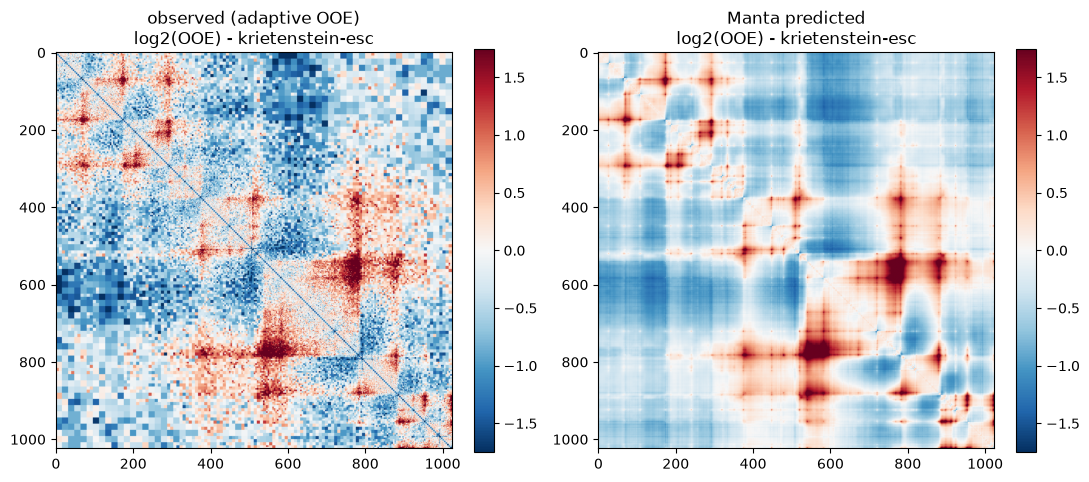

pearson of log2(OOE), predicted vs observed: 0.782


In [4]:
obs = infer.target(chrom, start_bp, adaptive_coarsegrain=True)   # [channels, N, N] observed OOE, smoothed

c = 0                                                # channel 0 = krietenstein-esc
def log2ooe(m):
    a = m.detach().cpu().float().numpy()
    return np.log2(np.where(a > 0, a, np.nan))
P, O = log2ooe(pred[c]), log2ooe(obs[c])
v = np.nanpercentile(np.abs(np.concatenate([P[np.isfinite(P)], O[np.isfinite(O)]])), 99)

fig, ax = plt.subplots(1, 2, figsize=(11, 5.2))
for a, img, ttl in ((ax[0], O, "observed (adaptive OOE)"), (ax[1], P, "Manta predicted")):
    im = a.imshow(img, cmap="RdBu_r", vmin=-v, vmax=v)
    a.set_title(f"{ttl}\nlog2(OOE) - {names[c]}"); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

m = np.isfinite(P) & np.isfinite(O)
print("pearson of log2(OOE), predicted vs observed:", round(float(np.corrcoef(P[m], O[m])[0, 1]), 3))

> **Match the cache to the model.** A MicroZoi cache must be built with the same MicroZoi weights the Manta
> model was trained against. If a prediction looks terribly wrong (a square with random stripes), the most likely cause is
> pairing the model with the **wrong cache**. This demo bundles the Krietenstein model with a matching cache;
> the full genome-wide caches live on the shared host.

## 3. Mutate: silence a region

`predict_region` takes a dict of conditions; with `backgrounds="matched"` (the default) the wild type and
mutant share the same cache backgrounds, so their difference isolates the edit. Mutations are tuples --
`("inactivate", lo, hi)` scrambles a region into inert sequence; others are `("replace", pos, seq)`,
`("invert", lo, hi)`, `("shuffle2", lo, hi)`. A mutation recomputes MicroZoi locally, so it needs the FASTA.

We typically use length preserving mutations. Non-length-preserving mutations (deletions) do not allow for a clean 
comparison of mutant vs WT. A list of allowed mutations: 
* `inactivate` - replaced with 4nt-shuffled quiescent sequence
* `invert`  - invert
* `shuffleX` with X=2,3,4,etc.  - shuffle preserving X nt content. 2 to 4 is recommended for short/long sequences. 

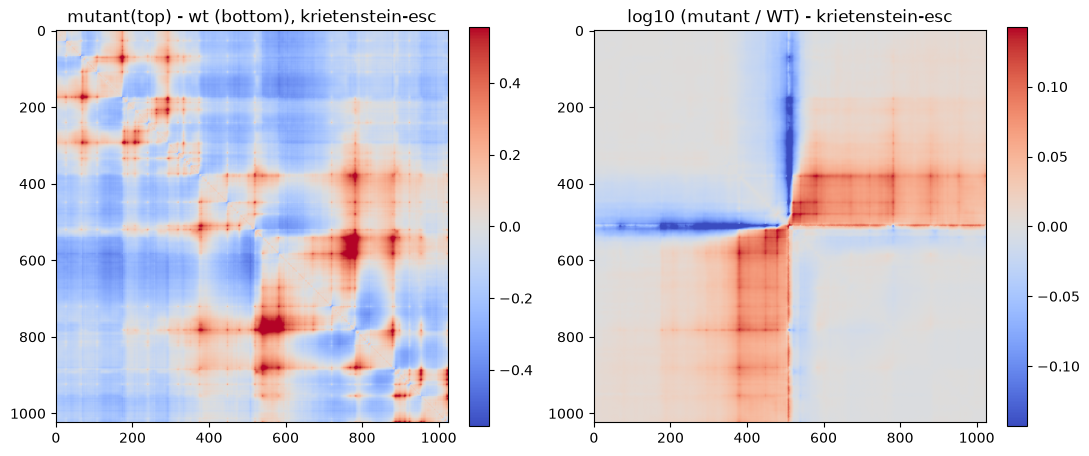

In [5]:
import pysam
fetcher.fasta_open = pysam.FastaFile(FASTA)          # mutations need the genome sequence

E = ("inactivate", start_bp + 1_030_000, start_bp + 1_050_000)   # silence a 20 kb region mid-window by replacing with a shuffled quiescent sequence
mm, _ = infer.predict_region(chrom, start_bp, {"WT": [], "mut": [E]}, runs=2)

mut = mm["mut"][c].log10().detach().cpu().numpy() 
wt = mm["WT"][c].log10().detach().cpu().numpy()

comparison = np.triu(mut) + np.tril(wt)
p = np.nanpercentile(np.abs(comparison), 99.5)

diff = mut - wt  # log10(mut) - log10(wt), which is log10(mut/wt)
d = np.nanpercentile(np.abs(diff), 99.5)


plt.figure(figsize=(11, 5))
plt.subplot(121)
plt.imshow(comparison, cmap="coolwarm", vmin=-p, vmax=p)
plt.title(f"mutant(top) - wt (bottom), {names[c]}")
plt.colorbar(fraction=0.046)

plt.subplot(122)
plt.imshow(diff, cmap="coolwarm", vmin=-d, vmax=d)
plt.title(f"log10 (mutant / WT) - {names[c]}")
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()